In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_price = pd.read_csv("../data/processed/cleaned_eth_price.csv")
df_post = pd.read_csv("../data/processed/cleaned_eth_post.csv")



In [2]:
print(df_post['score'].max())
print(df_post['score'].min())
print(df_post.head())

2507
-314
   created_utc subreddit                                               body  \
0   1579408968  ethereum    yeah that s infallible logic you re using there   
1   1579408860  ethereum                                 remindme  6 months   
2   1579408651  ethereum    thats what people said here about 2018 and 2019   
3   1579408630  ethereum  my comment is 100  accurate    according to th...   
4   1579407990  ethereum  risk of a smart contract being hacked  if ther...   

   score        Date  vader_scores  
0      6  2020-01-19        0.2960  
1      3  2020-01-19        0.0000  
2     -5  2020-01-19        0.0000  
3    -13  2020-01-19       -0.2023  
4      2  2020-01-19        0.2732  


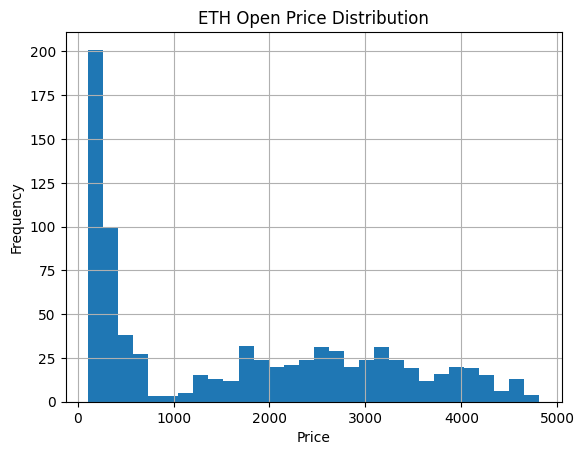

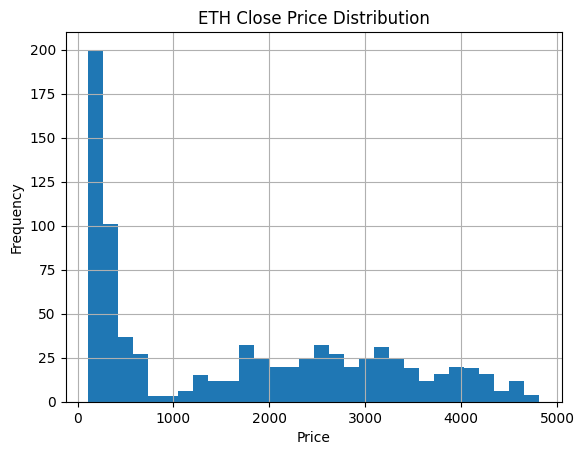

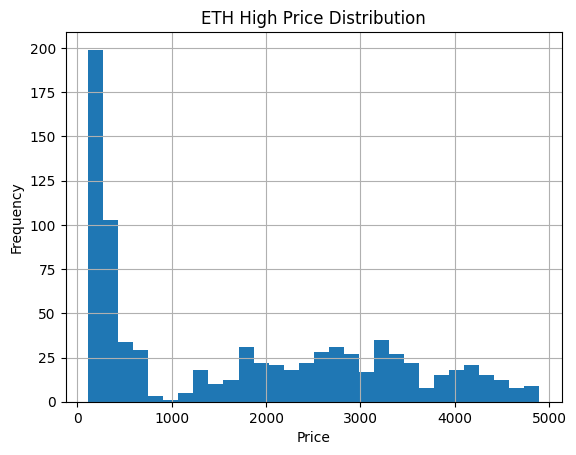

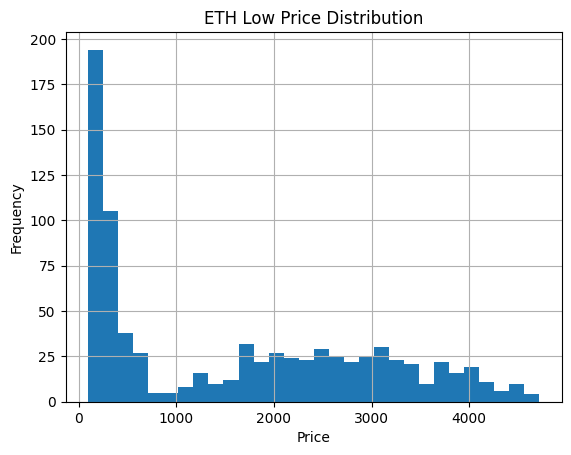

In [3]:
# Histo Analysis of df_price
df_price['Open'].astype(float).hist(bins=30)
plt.title('ETH Open Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['Close'].astype(float).hist(bins=30)
plt.title('ETH Close Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['High'].astype(float).hist(bins=30)
plt.title('ETH High Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

df_price['Low'].astype(float).hist(bins=30)
plt.title('ETH Low Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()




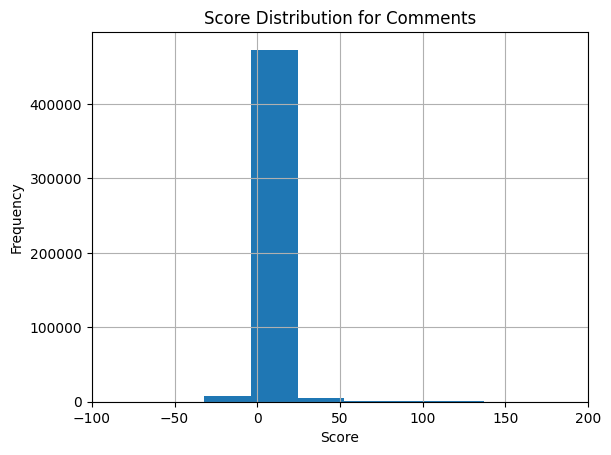

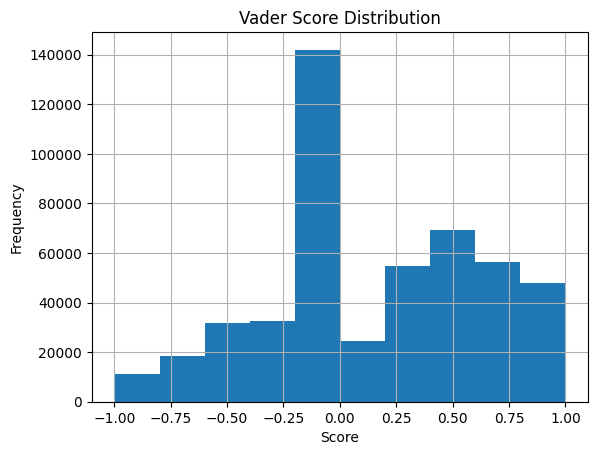

In [4]:
# Histo Analysis of df_post

df_post["score"].hist(bins=100)
plt.title("Score Distribution for Comments")
plt.xlabel("Score")
plt.xlim(-100, 200)
plt.ylabel("Frequency")
plt.show()

# Most score in range ~-10 to 25

df_post["vader_scores"].hist(bins=10)
plt.title("Vader Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


Sample positive posts:
12    with 32 eth you can be a  staker  in the new e...
13    but at the same time  don t cry about the rich...
21    gt  whether or not the communities want it is ...
24    if you have under 32 you have no option but to...
38                           that s good advice  thanks
Name: body, dtype: object
Sample negative posts:
22    the first phase of eth2 goes live this year   ...
23                                         no one cares
37    there are no staking rewards in ethereum  try ...
50    this is such a deceptive video thumbnail  i ju...
59                      and craig wright is just stupid
Name: body, dtype: object


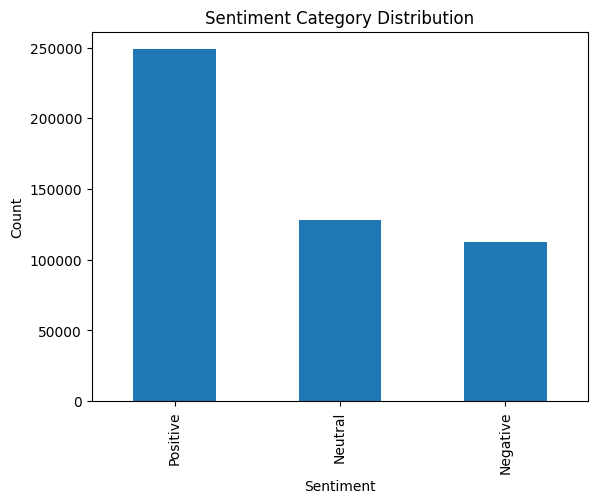

In [5]:
# Compare posts with highly positive and highly negative scores
positive_posts = df_post[df_post['vader_scores'] > 0.5]
negative_posts = df_post[df_post['vader_scores'] < -0.5]
print('Sample positive posts:')
print(positive_posts['body'].head())
print('Sample negative posts:')
print(negative_posts['body'].head())

# Group and visualize sentiment categories
def categorize_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_post['sentiment_category'] = df_post['vader_scores'].apply(categorize_sentiment)
sentiment_counts = df_post['sentiment_category'].value_counts()
sentiment_counts.plot(kind='bar')
plt.title('Sentiment Category Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


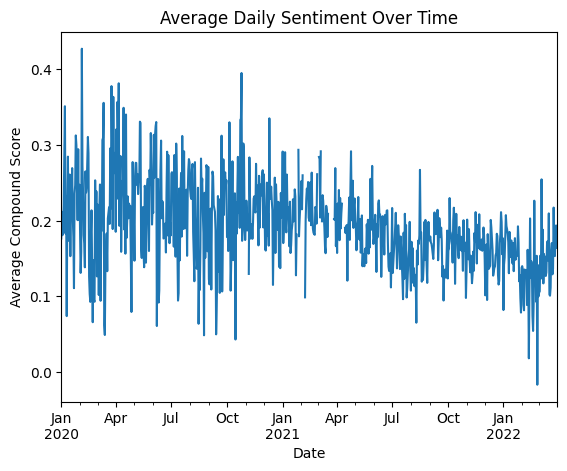

In [9]:
df_post['created_utc'] = pd.to_datetime(df_post['created_utc'], unit='s')
df_post.set_index('created_utc', inplace=True)
df_post.resample('D')['vader_scores'].mean().plot()
plt.title('Average Daily Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Compound Score')
plt.show()

In [7]:
# Reset index 
df_post.reset_index(inplace=True)

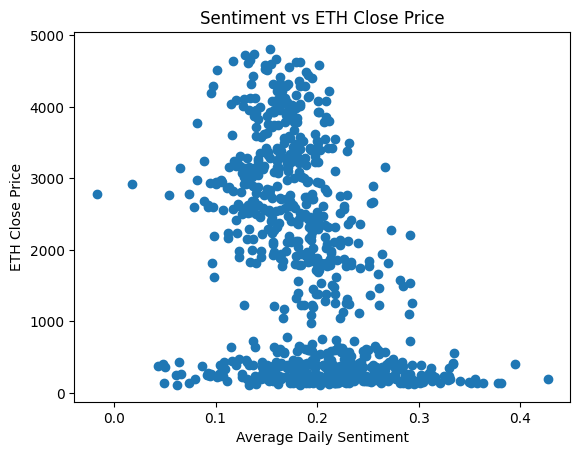

In [19]:
#  Correlate sentiment with ETH price
df_post['date'] = df_post.index.date
daily_sentiment = df_post.groupby('date')['vader_scores'].mean().reset_index()
df_price['Date'] = pd.to_datetime(df_price['Date']).dt.date
merged = pd.merge(daily_sentiment, df_price, left_on='date', right_on='Date')
plt.scatter(merged['vader_scores'], merged['Close'].astype(float))
plt.title('Sentiment vs ETH Close Price')
plt.xlabel('Average Daily Sentiment')
plt.ylabel('ETH Close Price')
plt.show()

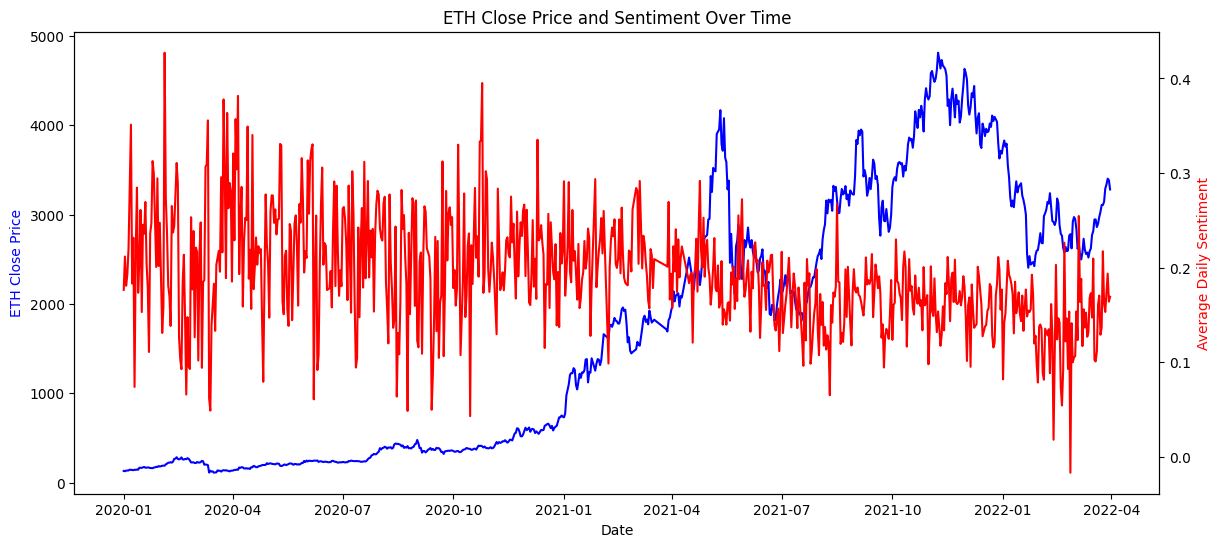

In [24]:
# Overlay ETH price and sentiment trends over time
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(merged['date'], merged['Close'], color='blue', label='ETH Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('ETH Close Price', color='blue')
ax2 = ax1.twinx()
ax2.plot(merged['date'], merged['vader_scores'], color='red', label='Average Daily Sentiment')
ax2.set_ylabel('Average Daily Sentiment', color='red')
plt.title('ETH Close Price and Sentiment Over Time')
plt.show()

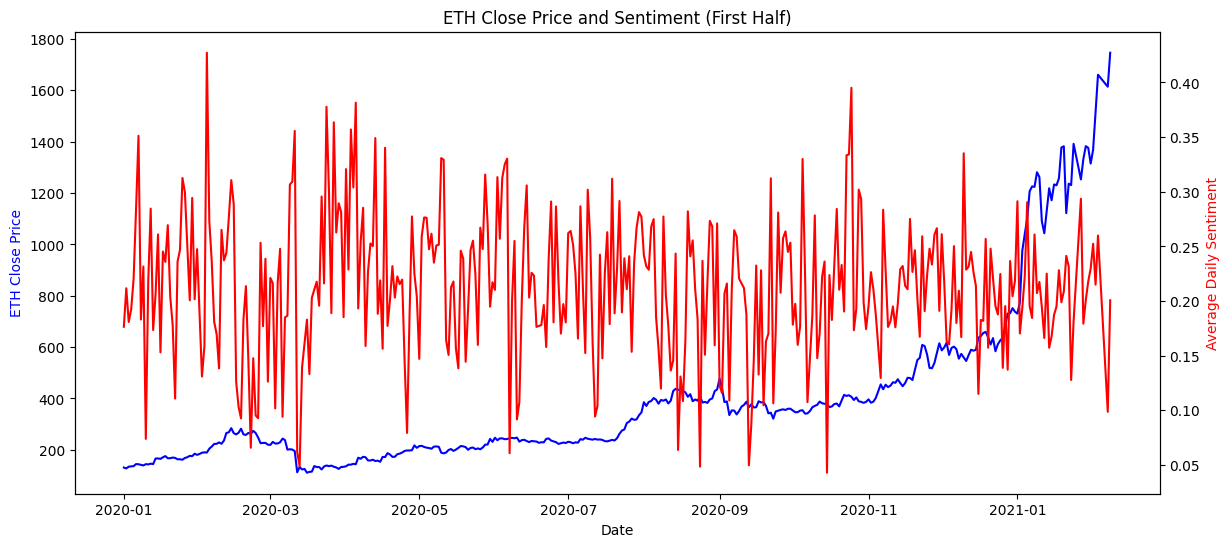

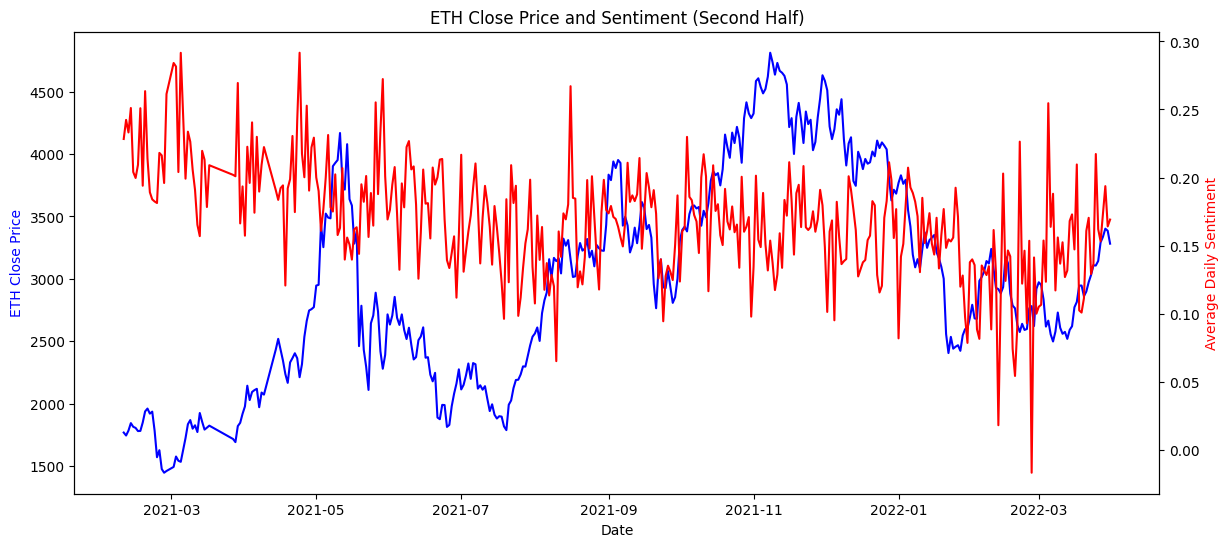

In [ ]:
# Split merged DataFrame into first and second halves by date
split_idx = len(merged) // 2
merged_first_half = merged.iloc[:split_idx]
merged_second_half = merged.iloc[split_idx:]

# first half
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(merged_first_half['date'], merged_first_half['Close'], color='blue', label='ETH Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('ETH Close Price', color='blue')
ax2 = ax1.twinx()
ax2.plot(merged_first_half['date'], merged_first_half['vader_scores'], color='red', label='Average Daily Sentiment')
ax2.set_ylabel('Average Daily Sentiment', color='red')
plt.title('ETH Close Price and Sentiment (First Half)')
plt.show()

# second half
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(merged_second_half['date'], merged_second_half['Close'], color='blue', label='ETH Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('ETH Close Price', color='blue')
ax2 = ax1.twinx()
ax2.plot(merged_second_half['date'], merged_second_half['vader_scores'], color='red', label='Average Daily Sentiment')
ax2.set_ylabel('Average Daily Sentiment', color='red')
plt.title('ETH Close Price and Sentiment (Second Half)')
plt.show()

In [25]:
# Calculate correlation coefficient between sentiment and ETH close price
correlation = merged['vader_scores'].corr(merged['Close'].astype(float))
print(f'Correlation between average daily sentiment and ETH close price: {correlation:.4f}')

Correlation between average daily sentiment and ETH close price: -0.4135


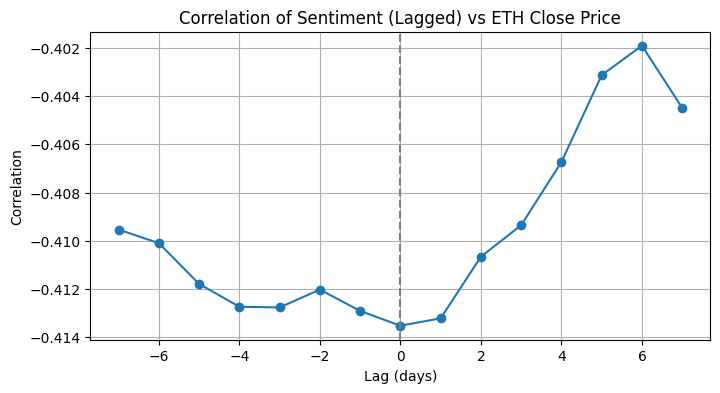

In [ ]:
# Lag shift analysis where we shifting sentiment
lags = range(-7, 8) 
correlations = []

for lag in lags:
    shifted = merged['vader_scores'].shift(lag)
    corr = shifted.corr(merged['Close'].astype(float))
    correlations.append(corr)

plt.figure(figsize=(8, 4))
plt.plot(lags, correlations, marker='o')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Correlation of Sentiment (Lagged) vs ETH Close Price')
plt.xlabel('Lag (days)')
plt.ylabel('Correlation')
plt.grid(True)
plt.show()

In [31]:
# Get the days with the highest and lowest sentiment
most_positive = merged.loc[merged['vader_scores'].idxmax()]
most_negative = merged.loc[merged['vader_scores'].idxmin()]

print("Most Positive Sentiment Day:")
print(most_positive[['date', 'vader_scores', 'Close']])

print("\nMost Negative Sentiment Day:")
print(most_negative[['date', 'vader_scores', 'Close']])

Most Positive Sentiment Day:
date            2020-02-04
vader_scores      0.427206
Close           189.250595
Name: 34, dtype: object

Most Negative Sentiment Day:
date             2022-02-26
vader_scores      -0.016843
Close           2781.111816
Name: 765, dtype: object


In [32]:
# Get the index of those days
pos_idx = merged['vader_scores'].idxmax()
neg_idx = merged['vader_scores'].idxmin()

# Show ETH price for the next 3 days after each event
print("\nETH Price After Most Positive Sentiment Day:")
print(merged.loc[pos_idx:pos_idx+3, ['date', 'Close']])

print("\nETH Price After Most Negative Sentiment Day:")
print(merged.loc[neg_idx:neg_idx+3, ['date', 'Close']])


ETH Price After Most Positive Sentiment Day:
          date       Close
34  2020-02-04  189.250595
35  2020-02-05  204.230240
36  2020-02-06  212.339081
37  2020-02-07  222.726059

ETH Price After Most Negative Sentiment Day:
           date        Close
765  2022-02-26  2781.111816
766  2022-02-27  2621.801758
767  2022-02-28  2919.201172
768  2022-03-01  2972.485107
